# Time-Frecuency
*  Jose Gonzalez Lopez
*  Mykola Liashuha

# Introduction
This is the intro

# Imports

In [7]:
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise

from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform

# Auxiliar Functions

In [8]:
'''
Signal-to-noise ratio
x: original signal
y: changed(noisy) signal
'''
def snr(x, y):
    return 20*np.log10(np.mean(np.abs(x))/np.mean(np.abs(x-y)))

In [45]:
'''
This function returns the general spectral substraction of a noisy signal
noisy_signal: noisy_signal with short fourier transform
lbda: lambda for formula, parameter we will discuss
power_density_spectrum: estimation of the power spectrum of original signal using welch method
alpha: alpha for formula, parameter we will discuss
beta: beta for formula, parameter we will discuss
gamma: gamma for formula, parameter we will discuss
'''

def spectral_substraction(noisy_signal,power_density_spectrum,lbda,alpha,beta,gamma):
    nsa=np.abs(noisy_signal)**alpha
    pdsa=np.abs(power_density_spectrum)**alpha
    lbdaa=lbda**alpha
    prod=lbdaa*pdsa
    
    if(all(nsa>prod)):
        up=lbdaa*pdsa
        down=nsa
        return noisy_signal*(1-(up/down))
    else:
        return ((gamma*noisy_signal)/(gamma*np.abs(noisy_signal))*np.abs(power_density_spectrum))
        

# Data

In [46]:
samplerate_music, data_music = wavfile.read("music.wav") #Read the file
ipd.Audio(data_music, rate=samplerate_music)

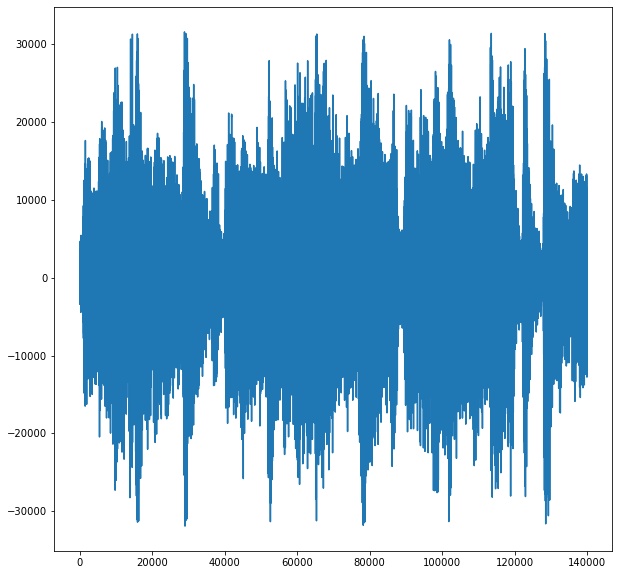

In [47]:
plt.figure(figsize=(10,10))
plt.plot(data_music)

# Noisy versions

In [48]:
stds = [130,70,40, 24,13]
noisy_musics=[]
for std in stds:
    noise = numpy.random.normal(0, 1, size=data_music.shape)
    data_music_noise = data_music + std*noise
    noisy_musics.append(data_music_noise)

In [32]:
x = data_music
noise = numpy.random.normal(0, 1, size=data_music.shape)
noise_gain = 140
n = noise_gain * noise

y = x + n

# Compute the SNR for signal x to noise n
y_snr = 10*np.log10(np.sum(x**2)/np.sum(n**2))
print("SNR: {:.2f}dB".format(y_snr))

SNR: -25.10dB


In [33]:
def audio_to_frames(y: np.array, m, hop_size, fs) -> np.array:
    """Convert y[n] into a matrix of frames Y_m(w) where each row is a time slice"""   
    _, _, Zxx = signal.stft(y, fs=fs, nperseg=m, noverlap=hop_size, nfft=m*8)
    return Zxx.T

def frames_to_audio(Y: np.array, m, hop_size, fs) -> np.array:
    """Convert Y_m(w) matrix of frames into a 1D signal y[n] using Overlap-Add"""
    _, xrec = signal.istft(Y.T, fs=fs, nperseg=m, noverlap=hop_size, nfft=m*8)
    return xrec

In [34]:
from scipy import signal
win_t = 30e-3 # window size in seconds
win_s = round(samplerate_music*win_t) # window size in samples
hop_size = win_s//2
Y = audio_to_frames(y, win_s, hop_size, samplerate_music)

In [35]:
Y.shape

(585, 1921)

In [36]:
def noise_estimation_snr(Y: np.array) -> (np.array, np.array):
    """Estimates the magnitude and power spectrum of the noise for each frame"""
    
    # Prepare the output variables
    est_Mn = np.zeros(Y.shape)
    est_Pn = np.zeros(Y.shape)
    
    N = 10 # Number of frames to use for estimating a-posteriori SNR
    
    # Iterate through each frame and estimate noise
    for m in range(Y.shape[0]):
        if m < N:
            # Use noisy spectra for first 10 iterations
            est_Mn[m] = abs(Y[m])
            est_Pn[m] = est_Mn[m] ** 2
        else:
            a = 25
            # A-posteriori SNR            
            gammak = (abs(Y[m])**2)/np.mean(abs(Y[m-N:m])**2, axis=0) 
            alpha = 1/(1+np.exp(-a*(gammak-1.5)))
            est_Mn[m] = alpha * abs(est_Mn[m-1]) + (1-alpha) * abs(Y[m])
            est_Pn[m] = alpha * (abs(est_Mn[m-1])**2) + (1-alpha) * (abs(Y[m])**2)
            
    return est_Mn, est_Pn
        
est_Mn, est_Pn = noise_estimation_snr(Y)

In [37]:
def spec_subtract_mag(Y, est_Mn) -> np.array:
    est_magX = np.maximum(abs(Y) - est_Mn, 0)
    est_phaseX = np.angle(Y)
    est_Sx = est_magX * np.exp(1j*est_phaseX)
    return est_Sx

def spec_subtract_pow(Y, est_Pn) -> np.array:
    est_powX = np.maximum(abs(Y)**2 - est_Pn, 0)
    est_phaseX = np.angle(Y)
    est_Sx = np.sqrt(est_powX) * np.exp(1j*est_phaseX)
    return est_Sx

est_Sx_mag = spec_subtract_mag(Y, est_Mn)
est_Sx_pow = spec_subtract_pow(Y, est_Pn)

In [38]:
from IPython.display import Audio
import IPython.display

# Noisy audio
print("Noisy audio")
IPython.display.display(Audio(y, rate=samplerate_music))

# Clean audio
print("Clean audio")
IPython.display.display(Audio(x, rate=samplerate_music))

# Estimate based on magnitude spectral subtraction
x_hat_mag = frames_to_audio(est_Sx_mag, win_s, hop_size, samplerate_music)[:len(x)]
print("Estimate based on magnitude spectral subtraction")
IPython.display.display(Audio(x_hat_mag, rate=samplerate_music))

# Estimate based on power spectral subtraction
x_hat_pow = frames_to_audio(est_Sx_pow, win_s, hop_size, samplerate_music)[:len(x)]
print("Estimate based on power spectral subtraction")
IPython.display.display(Audio(x_hat_pow, rate=samplerate_music))

Noisy audio


Clean audio


Estimate based on magnitude spectral subtraction


Estimate based on power spectral subtraction


# Spectral Substraction

In [49]:
denoised_signals=[]
for data_music_noise in noisy_musics:
    f_stft,t,Zxx=stft(data_music_noise) #Do inverse transform
    f, P_den = welch(data_music_noise, samplerate_music) #Get spectral density
    
    #MMMMMMMMMM
    f_stft+=0.000001
    
    denoised_signal=spectral_substraction(f_stft,P_den,1,2,0.5,0.00001)
    denoised_signals.append(denoised_signal)
    

In [50]:
denoised_signals[0]

array([5.93800931e+03, 3.36147427e+04, 7.78042895e+04, 9.67064466e+04,
       8.66170936e+04, 4.70745030e+04, 3.81068013e+04, 4.78084201e+04,
       2.86323344e+04, 2.28115810e+04, 2.81200905e+04, 4.29113189e+04,
       2.06268513e+04, 1.71165427e+04, 5.07780296e+04, 7.67905881e+04,
       2.09233380e+04, 1.23208890e+04, 5.70072962e+03, 2.18748900e+04,
       5.55753604e+04, 1.39679055e+04, 1.14433056e+04, 8.90639182e+03,
       1.42479461e+03, 2.38929131e+03, 1.47846173e+03, 9.86399555e+02,
       2.04197451e+03, 6.45983697e+03, 1.71179283e+04, 3.94564955e+03,
       2.75243068e+02, 6.23707994e+02, 8.96657439e+02, 2.88524230e+02,
       1.75592683e+02, 3.30660540e+02, 5.51393612e+02, 2.01860582e+02,
       6.32036496e+02, 2.74894365e+02, 1.10590533e+02, 8.91022676e+01,
       1.63837979e+02, 5.67219219e+02, 1.85516406e+02, 4.50411280e+01,
       3.61166069e+01, 1.61989327e+01, 4.75178538e+01, 5.39752772e+01,
       1.46746191e+01, 1.57321051e+01, 1.96085667e+01, 1.04584189e+01,
      

# Denoising

In [51]:
ipd.Audio(denoised_signals[0], rate=samplerate_music)

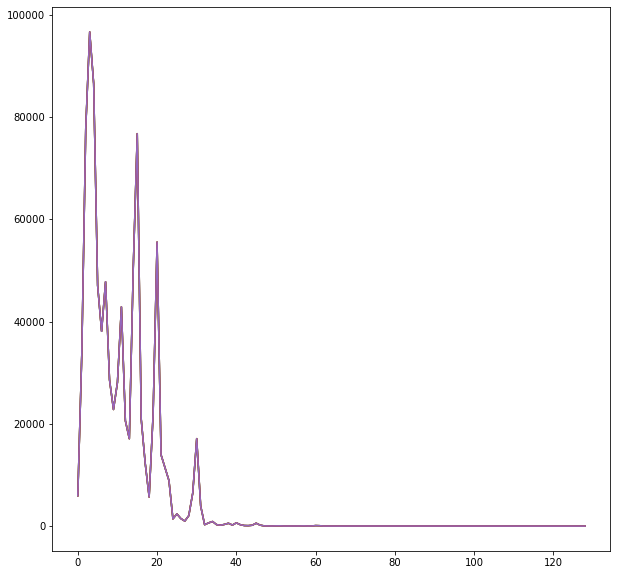

In [41]:
plt.figure(figsize=(10,10))
for denoised_signal in denoised_signals:
    plt.plot(denoised_signal)
    
plt.show()

# Discussion parameters

DISCUSSION

# Conclusions

CONCLUSIONS